<span style='font-family: Avenir; font-size:xx-large; font-weight:bolder'>
1. First use of Drosben
</span>

---

# 1A. Overview

This notebook assumes that you already:
- have [printed/assembled the drosben hardware](../hardware/README.md); and
- have [installed the drosben software](../README.md).

Past these steps the Drosben software works in three parts (in orange in the schematic), of which the first one will be covered here: 
![overview_software](../img/overview_soft1.png)

The reason for this step is that we need three colours to ensure all the data is potentially recorded:

![data_recording](../img/data_recording.png)

---

# 1B. Colour calibration of your marker pens

You will need to do this once before you set up your first experiment. If you do not change your marker pens, you might never have to do it again.

## Colour calibration overview

Before you spend precious time collecting data, the 'colour calibration step' makes sure that:
- the colours you use can be automatically discriminated once digitalised with your scanner system, and
- these colours and their correspondence to events are recorded, so they can be incorporated into the data compilation of future experiments.

The software will generate:
- a PDF report that will tell you how well it performs at distinguishing the pen colours (as imaged with your scanning/photo device). Then you decide whether to go ahead or try a different combination of pens.
- a binary file that captures the detected colours, so you incorporate this to your experimental designs.

These files will be created in:
```
your-home-directory/
│
├──Drosben_userdata/                               # created automatically
│   ├──colour_configurations/                      # created automatically
│   │   ├──ColourCalReport_YYYY-MM-DD_hh-mm-ss.pdf # human readable
│   │   ├──ColourConfig_YYYY-MM-DD_hh-mm-ss.pkl    # to use later
│   │   └──...
│   │
│   └──experiments_data/                           # created automatically
│
└──...
```

## Print and fill the Colour Calibration Sheet 

- First, [click here open the Colour Calibration Sheet](../src/drosben/resources/colour_cal_printout.pdf) and print it out.

- Second, fill it as instructed with marker pens of 3 different colours.

> We use red, green and blue Sharpie fine point pens, but have tested several others (including some more colourblind-friendly):
> ![marker_pens](../img/colour_combos.png)

<div class="alert alert-block alert-warning">
<b>Warning:</b> Not all combinations or individual colours work equally well. Yellow, light blue an light green need clear, large marks or they will fail to be detected. Brown has low saturation and may be confused with yellow/orange/red.
</div>

- Scan the filled calibration sheet it at >=150dpi of resolution if possible.

> We have tested flatbed scanners, phones and a photocopy machine for this step. **Flatbed scanners** are our best option because, while slow, they provide homogeneous, reproducible illumination, no perspective distortion, and custom resolution. Some **photocopy machines** do not allow choice of resolution, which can be critical. Phones will work provided you can ensure homogeneous, reproducible illumination (i.e. LED ring), frontal imaging (i.e. with a rig) and papers with no creases or folds (i.e. recently used or flattened with non-reflective clear sheet).

## `DRY RUN:` Load _test samples_ of colour calibration scans

To make sure the software runs, let's start by using sample colour calibration scans included in the repository.

To load the scan for red, green and blue markers, and display it:

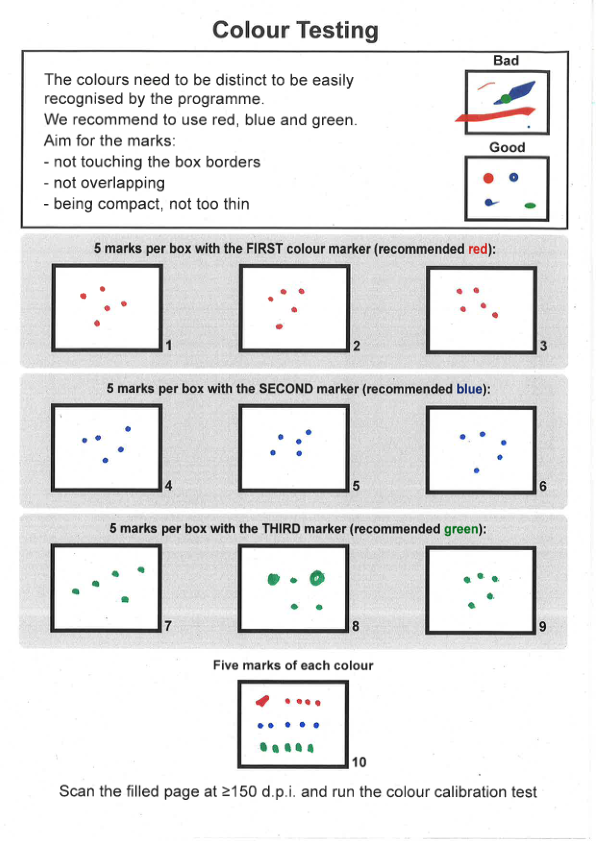

In [1]:
from pathlib import Path
imgpath = Path('../tests/data/scan_RGB_Xerox.pdf')
from drosben.image.utils import read_scan
img = read_scan(imgpath)
from PIL import Image
Image.fromarray(img)

Now we can evaluate how well are these colours detected and differentiated from each other:

In [69]:
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore', category = FutureWarning)
from drosben.image.colourcal import colour_calibration
import shutil
reportpath = colour_calibration(imgpath)
shutil.copy(reportpath, reportpath.name)
display(HTML(f'<embed src={reportpath.name} width="100%" height="800px" type="application/pdf">'))

---
This should give you a mix of red, green and blue marks perfectly detected, but with the warning that the resolution of the scan is a bit too low (which you can ignore, as there are no other problems).

If you can see that, then the software is working well. If not, please consider [creating an issue in GitHub](https://docs.github.com/en/issues/tracking-your-work-with-issues/using-issues/creating-an-issue).

---

We have also a more colourblind-friendly colour calibration sample, if you would prefer it:

In [70]:
imgpath = Path('../tests/data/scan_YPlB_Xerox.pdf')
reportpath = colour_calibration(imgpath)
shutil.copy(reportpath, reportpath.name)
display(HTML(f'<embed src={reportpath.name} width="100%" height="800px" type="application/pdf">'))

## Load your own colour calibration scans

Once you have in your compuyter a scan file of your own colour calibration sheet(s) filled in. Select it either interactively or by typing in the appropriate breadcrumbs to build a path in the code block further below.

**For interactive selection run the next two blocks without altering them**

In [71]:
# INTERACTIVE
# run this code block without altering it or jump to "COMMAND-LINE"
home = str(Path.cwd() / '../tests/data') 
fc = FileChooser(f'{home}/')
fc.filter_pattern = ['*.tif', '*.tiff', '*.png', '*.jpg', '*.jpeg', '*.pdf']
fc.title = '<b>Select your Colour Calibration scan</b> (single clicks)'
display(fc)

FileChooser(path='/Users/JQ/Documents/__REPOS/GitHub/MultiFlipper/tests/data', filename='', title='<b>Select y…

In [73]:
imgpath = Path(fc.selected)
print("/".join(fc.selected.split("/")[-3:]))

tests/data/scan_RGB_Xerox.pdf


**For command-line _instead_, run the next block:**

In [74]:
# COMMAND-LINE
# run this after editing:
# substitute the 'breadcrumbs' of the example with your path elements:
imgpath_cli = Path.home() / "path" / "to" / "colour_calibration_scan"
print(f'This path IS {"" if imgpath_cli.is_file() else "NOT "}a local file:')
print("/".join(str(imgpath_cli).split("/")[-3:]))

This path IS NOT a local file:
path/to/colour_calibration_scan


---
This captures the location of the file in your computer. Now run the next one to pass the location to the 'calibration' function.

In [76]:
usedpath = imgpath_cli if imgpath_cli.exists() else imgpath
reportpath = colour_calibration(usedpath)
shutil.copy(reportpath, reportpath.name)
print(f'\nReport for colour calibration scan file: {usedpath}\n')
display(HTML(f'<embed src={reportpath.name} width="100%" height="800px" type="application/pdf">'))


Report for colour calibration scan file: /Users/JQ/Documents/__REPOS/GitHub/MultiFlipper/tests/data/scan_RGB_Xerox.pdf



---

# 1C. Consider the results

The reports should be straight-forward to interpret. If there are any problems with a scan, the report will highlight them, and you will be able to see whether the colour hues are too close to each other. If the colouring in the report is not faithful to the original, it may be that the software is not working properly or that the scan is not homogeneously illuminated or does not have enough resolution.

> **Note:** This report will be saved in
>```
>your-home-directory/
>  └──Drosben_userdata/
>      └──colour_configurations/
>```

> Displaying it here will also save it next to the notebook:
>```
>drosben/
>  └──noteboooks/
>```

> You can delete this copy safely using the Jupyter Lab interface.

If you find problems, please consider [creating an issue in GitHub](https://docs.github.com/en/issues/tracking-your-work-with-issues/using-issues/creating-an-issue).



---
**END**

---